In [2]:
!pip install mlflow dagshub statsforecast kaggle -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.

In [ ]:
import os
import dagshub
import mlflow

mlflow.end_run()

dagshub.init(
    repo_owner='tsarc21',
    repo_name='Walmart-Recruiting---Store-Sales-Forecasting',
    mlflow=True
)
print("DagsHub & MLflow წარმატებით დაუკავშირდა ARIMA-ს ექსპერიმენტს!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c16f2ab1-75dd-4278-9f1f-340b93ef07ec&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=0c17bf40c692ad8cb6f176dd0786ad3ec0f36fcf100b26cc97dca8cc2a7fd041




Accessing as lkhar21

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub & MLflow წარმატებით დაუკავშირდა ARIMA-ს ექსპერიმენტს!


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API configured!")

Kaggle API configured!


In [ ]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

100% 2.70M/2.70M [00:00<00:00, 96.8MB/s]



In [ ]:
!unzip -q walmart-recruiting-store-sales-forecasting.zip

!unzip -q train.csv.zip
!unzip -q test.csv.zip
!unzip -q features.csv.zip
!unzip -q sampleSubmission.csv.zip

In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

print(train.shape)
print(features.shape)
print(stores.shape)

(421570, 5)
(8190, 12)
(45, 3)


In [ ]:
df = train.merge(features, on=["Store", "Date"], how="left")
df = df.merge(stores, on="Store", how="left")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Store", "Dept", "Date"])

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [ ]:
df["unique_id"] = (
    df["Store"].astype(str)
    + "_"
    + df["Dept"].astype(str)
)

arima_df = df.rename(columns={
    "Date": "ds",
    "Weekly_Sales": "y"
})

arima_df = arima_df[
    ["unique_id", "ds", "y"]
].copy()

arima_df.head()

,unique_id,ds,y
0,1_1,2010-02-05,24924.50
1,1_1,2010-02-12,46039.49
2,1_1,2010-02-19,41595.55
3,1_1,2010-02-26,19403.54
4,1_1,2010-03-05,21827.90


In [ ]:
series_lengths = arima_df.groupby("unique_id").size()

series_lengths.describe()

,0
count,3331.000000
mean,126.559592
std,40.212763
min,1.000000
25%,143.000000
50%,143.000000
75%,143.000000
max,143.000000


In [ ]:
valid_ids = series_lengths[series_lengths >= 30].index

arima_df = arima_df[
    arima_df["unique_id"].isin(valid_ids)
]

print(arima_df["unique_id"].nunique())

3053


In [ ]:
# ბოლო 12 კვირა validation
cutoff = arima_df["ds"].max() - pd.Timedelta(weeks=12)

train_df = arima_df[arima_df["ds"] <= cutoff].copy()
val_df = arima_df[arima_df["ds"] > cutoff].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

print(train_df["ds"].min(), train_df["ds"].max())
print(val_df["ds"].min(), val_df["ds"].max())

Train: (383651, 3)
Validation: (35371, 3)
2010-02-05 00:00:00 2012-08-03 00:00:00
2012-08-10 00:00:00 2012-10-26 00:00:00


In [ ]:
mlflow.set_experiment("ARIMA_Training")

2026/07/05 08:03:52 INFO mlflow.tracking.fluent: Experiment with name 'ARIMA_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/5ac6050e5d37412e84bfb068b01b526b', creation_time=1783238632492, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1783238632492, lifecycle_stage='active', name='ARIMA_Training', tags={}, trace_location=None, workspace='default'>

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

In [ ]:
models = [
    AutoARIMA(
        seasonal=False
    )
]

sf = StatsForecast(
    models=models,
    freq="W-FRI",
    n_jobs=-1
)

In [ ]:
# ავიღოთ მხოლოდ პირველი 50 time series
sample_ids = train_df["unique_id"].unique()[:50]

train_small = train_df[
    train_df["unique_id"].isin(sample_ids)
].copy()

val_small = val_df[
    val_df["unique_id"].isin(sample_ids)
].copy()

print("Train:", train_small.shape)
print("Validation:", val_small.shape)
print("Series:", train_small["unique_id"].nunique())

Train: (6332, 3)
Validation: (578, 3)
Series: 50


In [ ]:
forecast = sf.forecast(
    df=train_small,
    h=12
)

forecast.head()

,unique_id,ds,AutoARIMA
0,1_1,2012-08-10,20074.815168
1,1_1,2012-08-17,22077.517578
2,1_1,2012-08-24,22546.923476
3,1_1,2012-08-31,22656.945762
4,1_1,2012-09-07,22682.733472


In [ ]:
eval_df = val_small.merge(
    forecast,
    on=["unique_id", "ds"],
    how="inner"
)

print(eval_df.shape)
eval_df.head()

(571, 4)


,unique_id,ds,y,AutoARIMA
0,1_1,2012-08-10,16119.92,20074.815168
1,1_1,2012-08-17,17330.70,22077.517578
2,1_1,2012-08-24,16286.40,22546.923476
3,1_1,2012-08-31,16680.24,22656.945762
4,1_1,2012-09-07,18322.37,22682.733472


In [ ]:
forecast = forecast.rename(columns={"AutoARIMA": "y_pred"})

In [ ]:
eval_df = val_small.merge(
    forecast,
    on=["unique_id", "ds"],
    how="left"
)

In [ ]:
eval_df[["y", "y_pred"]].dropna().head()

,y,y_pred
0,16119.92,20074.815168
1,17330.70,22077.517578
2,16286.40,22546.923476
3,16680.24,22656.945762
4,18322.37,22682.733472


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

eval_df = eval_df.dropna()

mae = mean_absolute_error(eval_df["y"], eval_df["y_pred"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["y_pred"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2198.971076322494
RMSE: 3769.268179319078


In [ ]:
with mlflow.start_run(run_name="ARIMA_50series"):

    mlflow.log_param("model", "AutoARIMA")
    mlflow.log_param("series_count", 50)
    mlflow.log_param("freq", "W-FRI")

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)

🏃 View run ARIMA_50series at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4/runs/9ea9b2eceb934371953fe1b23714d4fb
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4


In [ ]:
eval_df = val_small.merge(
    forecast,
    on=["unique_id", "ds"],
    how="inner"
)

print(eval_df.shape)

(571, 4)


In [ ]:
print(eval_df.columns)

Index(['unique_id', 'ds', 'y', 'y_pred'], dtype='object')


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

eval_df = eval_df.dropna()

mae = mean_absolute_error(eval_df["y"], eval_df["y_pred"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["y_pred"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2198.971076322494
RMSE: 3769.268179319078


In [ ]:
with mlflow.start_run(run_name="ARIMA_50series"):

    mlflow.log_param("model", "AutoARIMA")
    mlflow.log_param("series_count", 50)
    mlflow.log_param("freq", "W-FRI")

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)

print("MLflow logged successfully ✅")

🏃 View run ARIMA_50series at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4/runs/0e79899c3a724fc294510762cb493d46
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4
MLflow logged successfully ✅


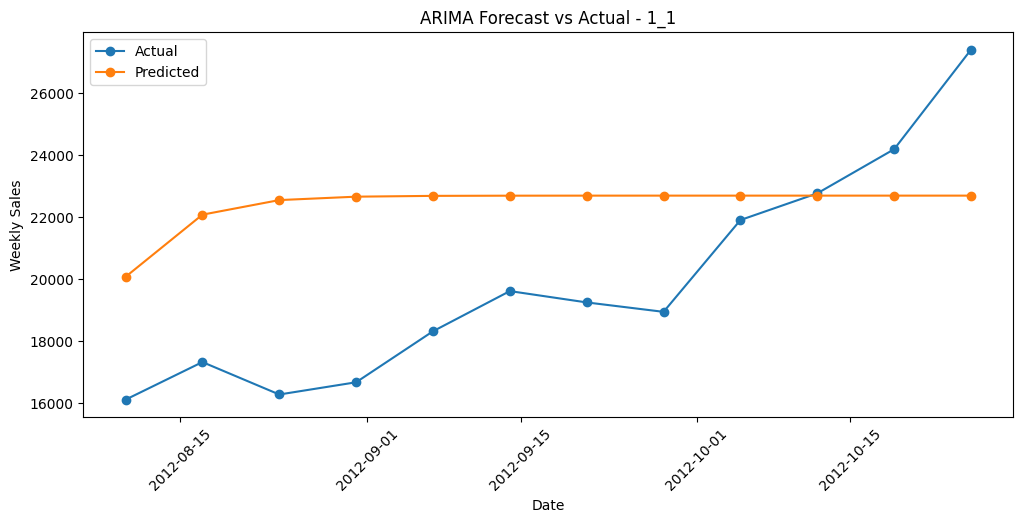

In [ ]:
import matplotlib.pyplot as plt

sample_id = eval_df["unique_id"].iloc[0]
df_plot = eval_df[eval_df["unique_id"] == sample_id]

plt.figure(figsize=(12,5))

plt.plot(df_plot["ds"], df_plot["y"], label="Actual", marker="o")
plt.plot(df_plot["ds"], df_plot["y_pred"], label="Predicted", marker="o")

plt.title(f"ARIMA Forecast vs Actual - {sample_id}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.xticks(rotation=45)

plt.show()

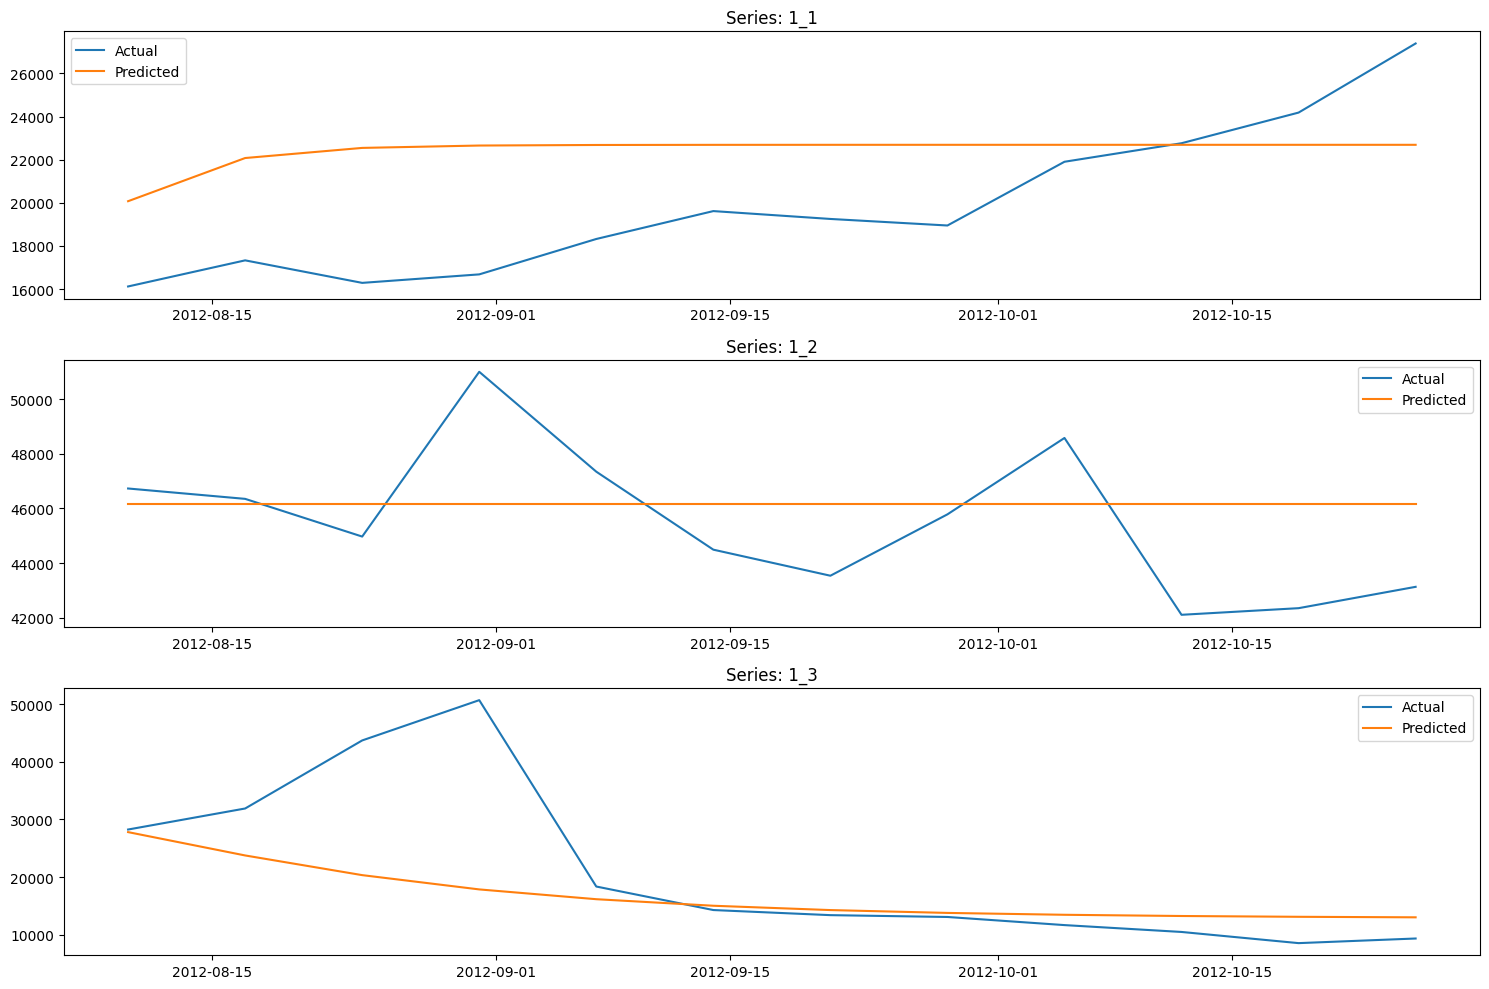

In [ ]:
import matplotlib.pyplot as plt

sample_ids = eval_df["unique_id"].unique()[:3]

plt.figure(figsize=(15,10))

for i, sid in enumerate(sample_ids):
    df_s = eval_df[eval_df["unique_id"] == sid]

    plt.subplot(3,1,i+1)
    plt.plot(df_s["ds"], df_s["y"], label="Actual")
    plt.plot(df_s["ds"], df_s["y_pred"], label="Predicted")

    plt.title(f"Series: {sid}")
    plt.legend()

plt.tight_layout()
plt.show()

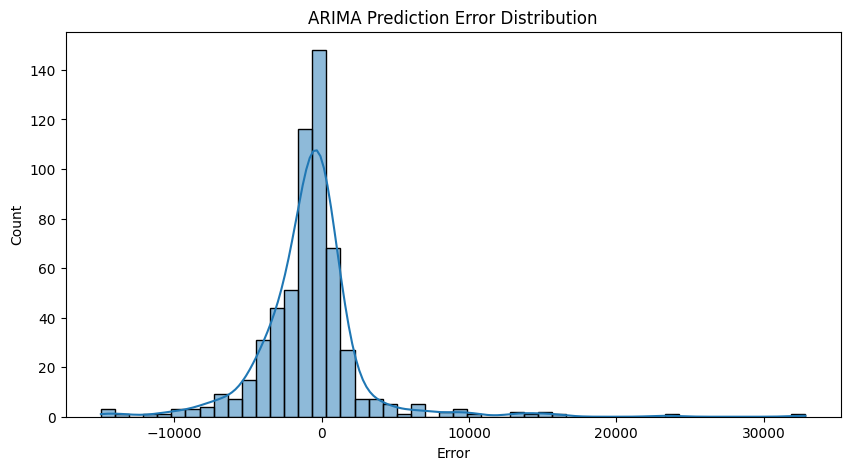

In [ ]:
import seaborn as sns

eval_df["error"] = eval_df["y"] - eval_df["y_pred"]

plt.figure(figsize=(10,5))
sns.histplot(eval_df["error"], bins=50, kde=True)

plt.title("ARIMA Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

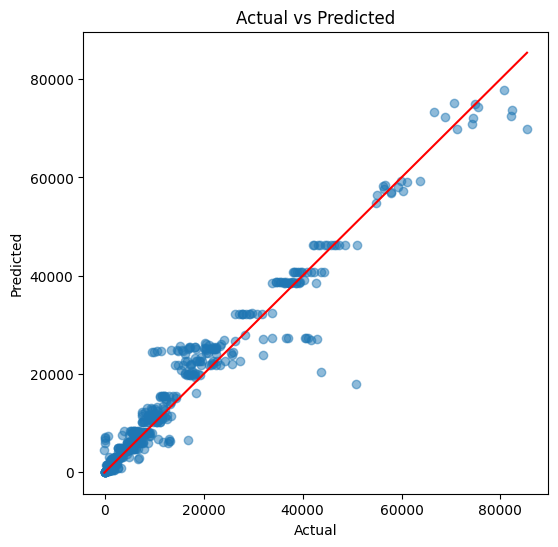

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(eval_df["y"], eval_df["y_pred"], alpha=0.5)

plt.plot(
    [eval_df["y"].min(), eval_df["y"].max()],
    [eval_df["y"].min(), eval_df["y"].max()],
    color="red"
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(eval_df["y"], eval_df["y_pred"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["y_pred"]))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 2198.97
RMSE: 3769.27


In [ ]:
mape = np.mean(np.abs((eval_df["y"] - eval_df["y_pred"]) / eval_df["y"])) * 100

print("MAPE (%):", round(mape, 2))

MAPE (%): 863.97


In [ ]:
baseline = eval_df.copy()
baseline["baseline_pred"] = eval_df.groupby("unique_id")["y"].shift(1)
baseline = baseline.dropna()

baseline_mae = mean_absolute_error(baseline["y"], baseline["baseline_pred"])

print("Baseline MAE:", baseline_mae)
print("ARIMA MAE:", mae)

Baseline MAE: 1510.6385659655832
ARIMA MAE: 2198.971076322494


In [ ]:
improvement = (baseline_mae - mae) / baseline_mae * 100

print("Improvement over baseline (%):", round(improvement, 2))

Improvement over baseline (%): -45.57


In [ ]:
print(f"""
MODEL SUMMARY
-------------
MAE: {mae:.2f}
RMSE: {rmse:.2f}
MAPE: {mape:.2f}%
Improvement vs baseline: {improvement:.2f}%
""")


MODEL SUMMARY
-------------
MAE: 2198.97
RMSE: 3769.27
MAPE: 863.97%
Improvement vs baseline: -45.57%



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# metrics
mae = mean_absolute_error(eval_df["y"], eval_df["y_pred"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["y_pred"]))

mape = np.mean(np.abs((eval_df["y"] - eval_df["y_pred"]) / eval_df["y"])) * 100

# baseline (naive)
baseline = eval_df.copy()
baseline["baseline_pred"] = eval_df.groupby("unique_id")["y"].shift(1)
baseline = baseline.dropna()

baseline_mae = mean_absolute_error(baseline["y"], baseline["baseline_pred"])

improvement = (baseline_mae - mae) / baseline_mae * 100

# summary print
print(f"""
MODEL SUMMARY
-------------
MAE: {mae:.2f}
RMSE: {rmse:.2f}
MAPE: {mape:.2f}%
Improvement vs baseline: {improvement:.2f}%
""")


MODEL SUMMARY
-------------
MAE: 2198.97
RMSE: 3769.27
MAPE: 863.97%
Improvement vs baseline: -45.57%

